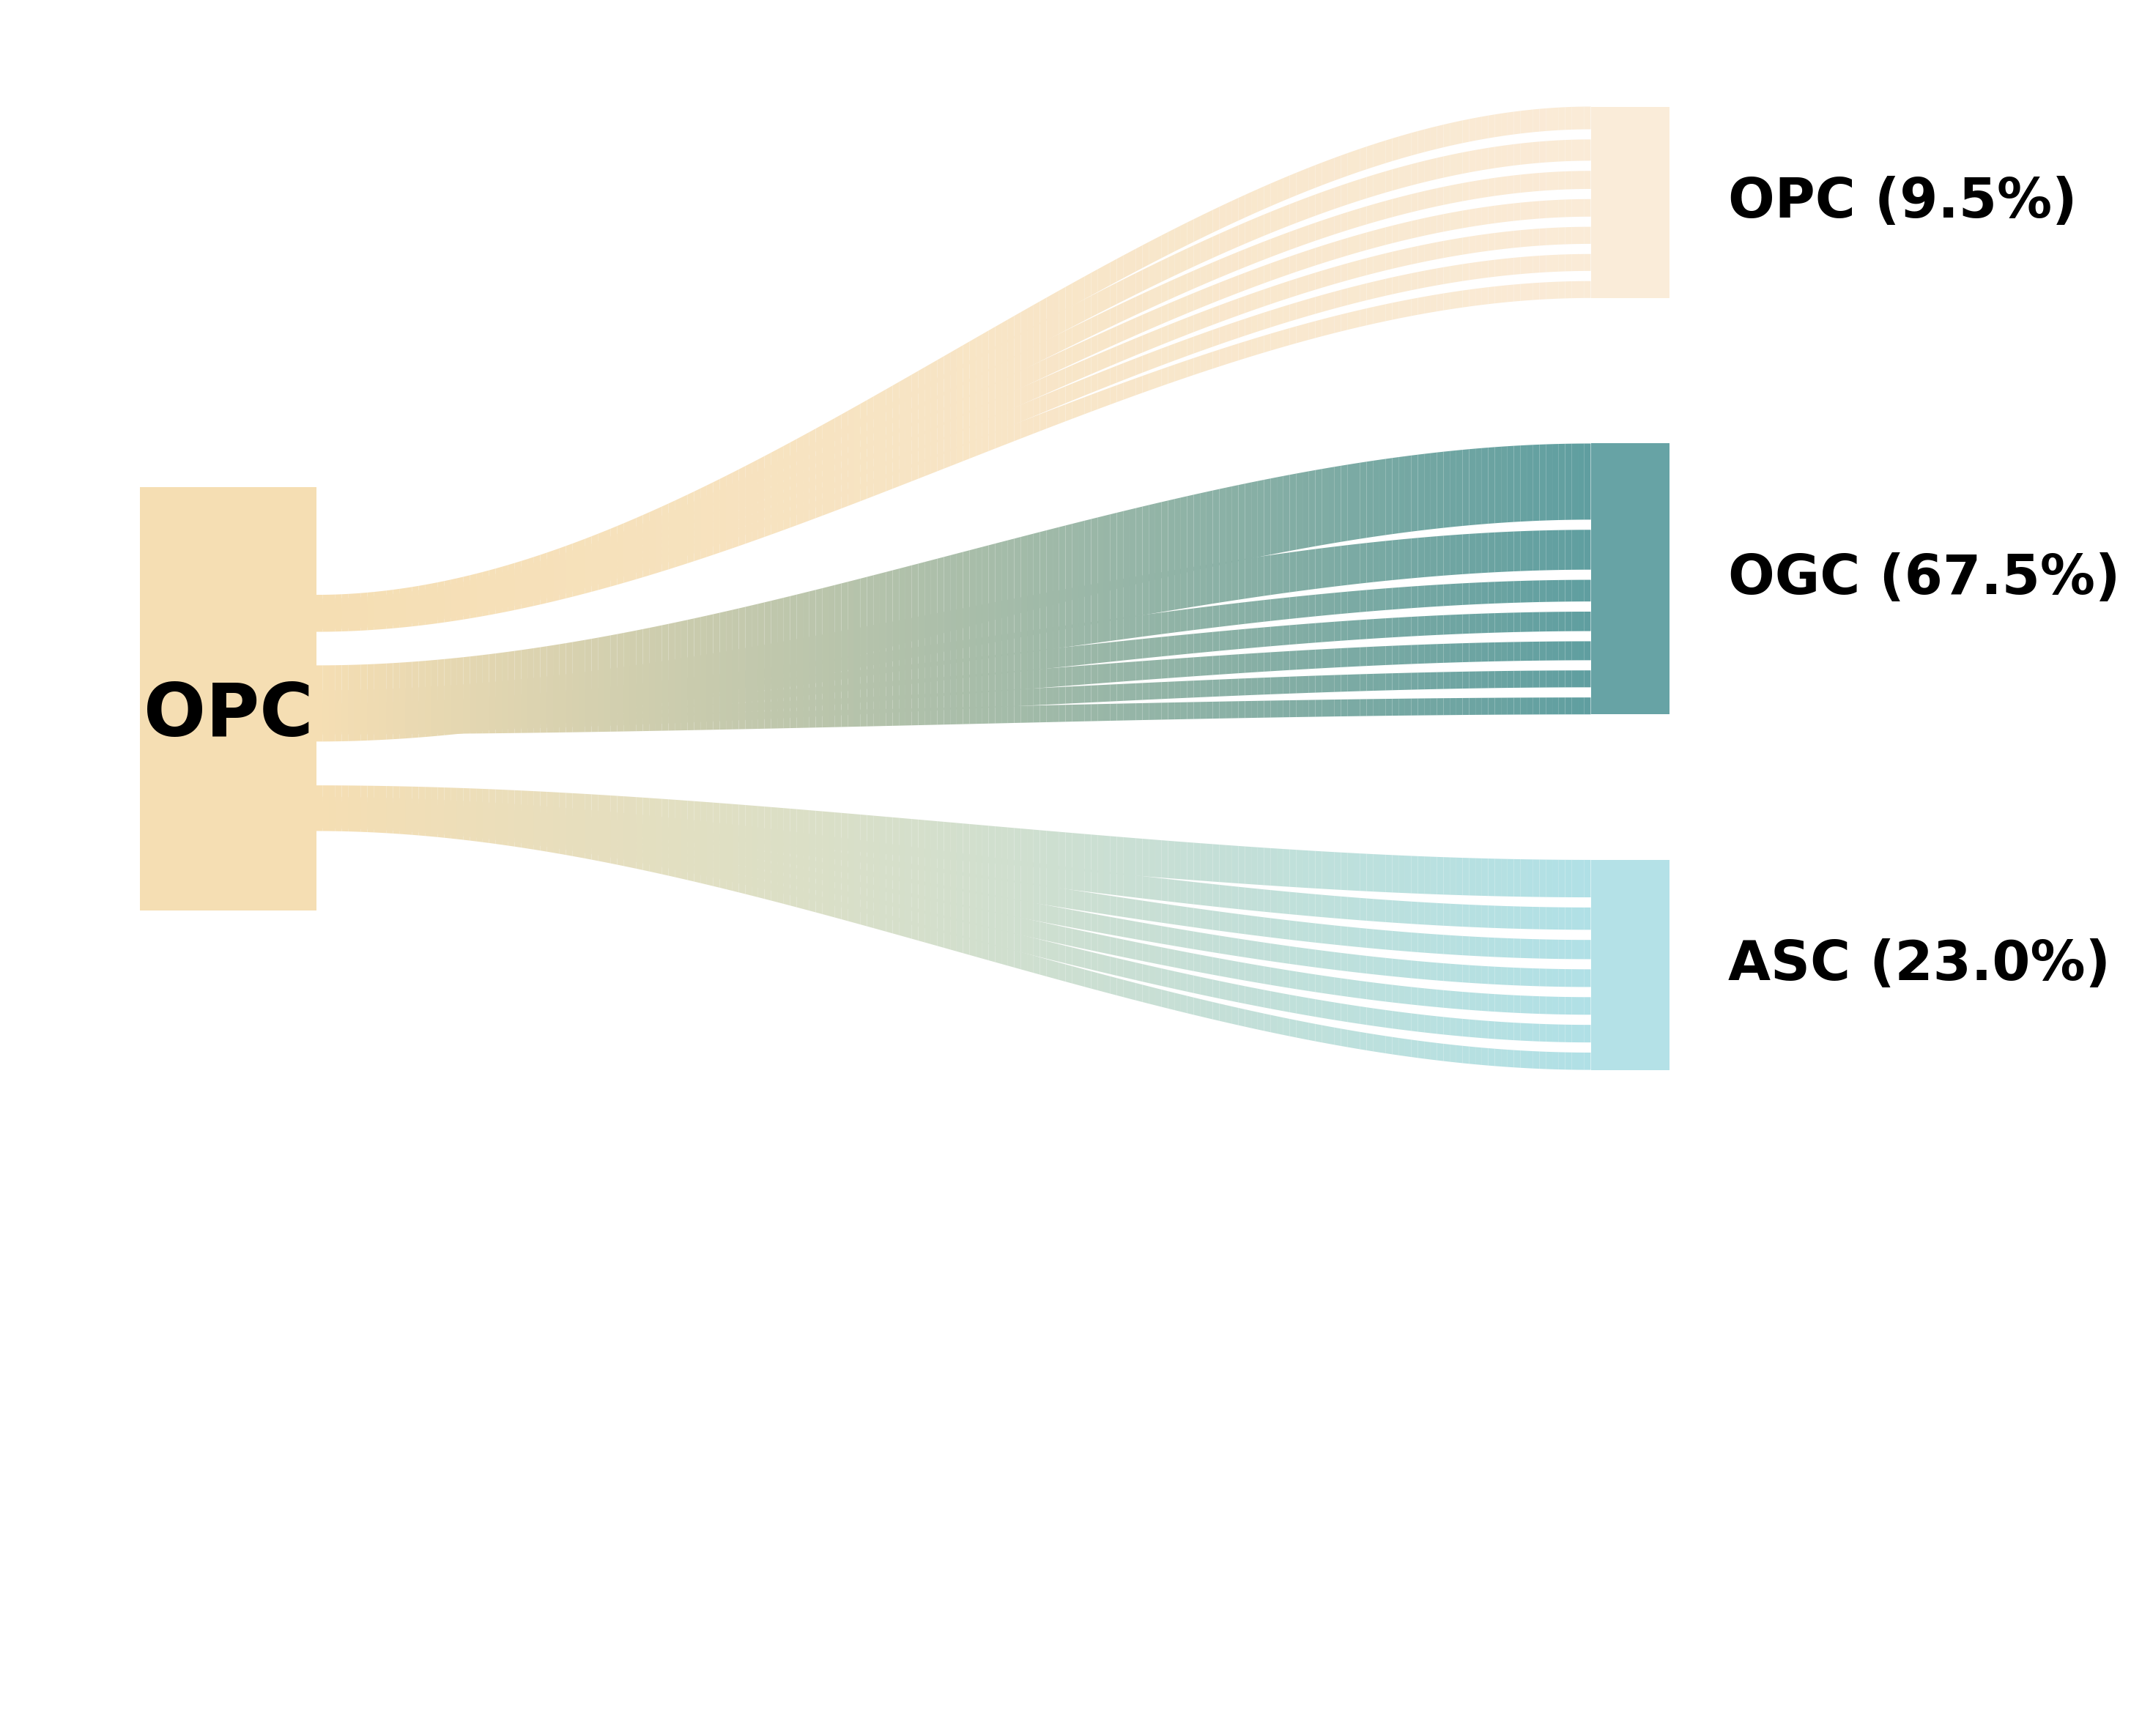

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Jun  2 21:40:39 2026

@author: mozhganoroujlu
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle, Polygon
from matplotlib.colors import LinearSegmentedColormap

# =====================================================
# LOAD DATA
# =====================================================

excel_file = "/Users/mozhganoroujlu/Desktop/SA/score/results/modif/generated/all_opcs/150n_e4_final_summary.xlsx"

df = pd.read_excel(
    excel_file,
    sheet_name="Detailed_Final_States"
)

# =====================================================
# COLORS
# =====================================================

base_colors = {
    "OGC": "#5F9EA0",
    "ASC": "#B0E0E6",
    "OPC": "#FAEBD7"
}

SOURCE_COLOR = "#F5DEB3"

# =====================================================
# DATA CLEANING
# =====================================================

df["cell type"] = df["cell type"].astype(str).str.strip()

group_order = ["OPC", "OGC", "ASC"]

df["group_rank"] = df["cell type"].map(
    {g: i for i, g in enumerate(group_order)}
)

df = (
    df.sort_values(
        ["group_rank",
         "total number counted as final state"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

# =====================================================
# THICKNESS SCALING
# =====================================================

counts = df["total number counted as final state"].values

min_w = 0.010
max_w = 0.045

if counts.max() == counts.min():
    widths = np.repeat(0.025, len(counts))
else:
    widths = (
        min_w
        + (counts - counts.min())
        / (counts.max() - counts.min())
        * (max_w - min_w)
    )

df["width"] = widths

# =====================================================
# DESTINATION POSITIONS
# =====================================================

group_gap = 0.08
barcode_gap = 0.006

positions = []

current_y = 0.95

for group in group_order:

    subset = df[df["cell type"] == group]

    for idx in subset.index:

        w = df.loc[idx, "width"]

        current_y -= w / 2
        positions.append((idx, current_y))
        current_y -= w / 2 + barcode_gap

    current_y -= group_gap

for idx, ypos in positions:
    df.loc[idx, "target_y"] = ypos

# =====================================================
# =====================================================
# SOURCE STACKING
# compact source with mild alignment
# =====================================================

total_height = (
    widths.sum()
    + barcode_gap * (len(df) - 1)
)

source_center = 0.5
source_bottom = source_center - total_height / 2

raw_segments = []

cur = source_bottom

for w in widths:

    y0 = cur
    y1 = cur + w

    raw_segments.append((y0, y1))

    cur = y1 + barcode_gap

# -----------------------------------------------------
# compress toward targets
# -----------------------------------------------------

alignment_strength = 0.55
# 0   = original
# 1   = fully horizontal
# 0.25-0.45 usually looks best

segments = []

for i, row in df.iterrows():

    w = row["width"]

    source_mid = (
        raw_segments[i][0]
        + raw_segments[i][1]
    ) / 2

    target_mid = row["target_y"]

    new_mid = (
        (1 - alignment_strength) * source_mid
        + alignment_strength * target_mid
    )

    segments.append(
        (
            new_mid - w / 2,
            new_mid + w / 2
        )
    )
# =====================================================
# FATE PERCENTAGES
# =====================================================

fate_counts = (
    df.groupby("cell type")
      ["total number counted as final state"]
      .sum()
)

total_final = fate_counts.sum()

fate_percent = (
    fate_counts / total_final * 100
)

# =====================================================
# FIGURE
# =====================================================

fig, ax = plt.subplots(
    figsize=(10, 8),
    dpi=300
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# =====================================================
# SOURCE BLOCK
# =====================================================

source_x0 = 0.06
source_x1 = 0.15

source_block_height = 0.25

source_block_bottom = 0.6 - source_block_height/2

ax.add_patch(
    Rectangle(
        (source_x0, source_block_bottom),
        source_x1 - source_x0,
        source_block_height,
        facecolor=SOURCE_COLOR,
        edgecolor="none"
    )
)

ax.text(
    0.062,
    0.59,
    "OPC",
    fontsize=24,
    fontweight="bold",
    va="center"
)

# =====================================================
# STRAIGHT GRADIENT RIBBON
# =====================================================

def draw_gradient_ribbon(
    ax,
    x0,
    x1,
    y0_low,
    y0_high,
    y1_low,
    y1_high,
    color_start,
    color_end,
    n=200
):

    t = np.linspace(0, 1, n)

    smooth = 3 * t**2 - 2 * t**3

    upper_x = np.linspace(x0, x1, n)
    lower_x = upper_x

    upper_y = (
        y0_high
        + (y1_high - y0_high) * smooth
    )

    lower_y = (
        y0_low
        + (y1_low - y0_low) * smooth
    )

    cmap = LinearSegmentedColormap.from_list(
        "flow",
        [color_start, color_end]
    )

    for i in range(n - 1):

        poly = np.array([
            [upper_x[i], upper_y[i]],
            [upper_x[i + 1], upper_y[i + 1]],
            [lower_x[i + 1], lower_y[i + 1]],
            [lower_x[i], lower_y[i]]
        ])

        ax.add_patch(
            Polygon(
                poly,
                closed=True,
                facecolor=cmap(i/(n-1)),
                edgecolor="none"
            )
        )
# =====================================================
# DRAW RIBBONS
# =====================================================

target_x = 0.80

for i, row in df.iterrows():

    width = row["width"]

    y_target = row["target_y"]

    y0_source, y1_source = segments[i]

    draw_gradient_ribbon(
        ax=ax,
        x0=source_x1,
        x1=target_x,
        y0_low=y0_source,
        y0_high=y1_source,
        y1_low=y_target - width / 2,
        y1_high=y_target + width / 2,
        color_start=SOURCE_COLOR,
        color_end=base_colors[row["cell type"]]
    )

# =====================================================
# DESTINATION BLOCKS
# =====================================================

block_x0 = 0.80
block_x1 = 0.84

for group in group_order:

    subset = df[df["cell type"] == group]

    if len(subset) == 0:
        continue

    ymin = (
        subset["target_y"]
        - subset["width"] / 2
    ).min()

    ymax = (
        subset["target_y"]
        + subset["width"] / 2
    ).max()

    ax.add_patch(
        Rectangle(
            (block_x0, ymin),
            block_x1 - block_x0,
            ymax - ymin,
            facecolor=base_colors[group],
            edgecolor="none",
            alpha=0.95
        )
    )

    pct = fate_percent[group]

    ax.text(
    0.87,
    (ymin + ymax) / 2,
    f"{group} ({pct:.1f}%)",
    fontsize=18,
    fontweight="bold",
    va="center"
)

# =====================================================
# SAVE
# =====================================================

plt.tight_layout()

plt.savefig(
    "OPC_fate_alluvial.pdf",
    dpi=600,
    bbox_inches="tight"
)



plt.savefig(
    "OPC_fate_alluvial.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
